# 고객 이용 특성과 계약 기간에 따른 이탈률 분석

## 컬럼 설명

| 컬럼명 | 설명 |
|---|---|
| `gender` | 고객의 성별 |
| `Near_Location` | 헬스장 근처 거주 여부 |
| `Partner` | 제휴 파트너를 통한 가입 여부 |
| `Promo_friends` | 친구 추천 프로모션을 통한 가입 여부 |
| `Phone` | 전화번호 제공 여부 |
| `Contract_period` | 고객의 계약 기간 |
| `Group_visits` | 그룹 운동 참여 여부 |
| `Age` | 고객의 나이 |
| `Avg_additional_charges_total` | 추가 서비스 이용에 따른 평균 추가 지출 금액 |
| `Month_to_end_contract` | 계약 종료까지 남은 기간(개월) |
| `Lifetime` | 헬스장 이용 기간(개월) |
| `Avg_class_frequency_total` | 전체 이용 기간 동안의 평균 월 방문 빈도 |
| `Avg_class_frequency_current_month` | 최근 월의 평균 방문 빈도 |
| `Churn` | 고객 이탈 여부 (`0`: 유지, `1`: 이탈) |


## 분석에 사용한 컬럼

| 컬럼명 | 설명 |
|---|---|
| `Lifetime` | 헬스장 이용 기간(개월) |
| `Age` | 고객의 나이 |
| `Avg_class_frequency_current_month` | 최근 월의 평균 방문 빈도 |
| `Contract_period` | 고객의 계약 기간 |
| `Churn` | 고객 이탈 여부 (`0`: 유지, `1`: 이탈) |

# 1. 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

# 차트 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

SEED = 42

# 데이터 블러오기
df = pd.read_csv('../data/gym_churn_us.csv')

df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


# 2. 데이터 기본정보 확인

In [2]:
# 데이터 기본 정보
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

In [3]:
# 수치형 데이터 확인
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [4]:
# 결측치 확인
df.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [5]:
# 데이터 중복 확인
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='str')

# 3. 데이터 정제

In [7]:
features = ['Lifetime', 'Age', 'Avg_class_frequency_current_month', 'Contract_period', 'Churn']

cluster_df = df[features].copy(deep=True)
cluster_df

,Lifetime,Age,Avg_class_frequency_current_month,Contract_period,Churn
0,3,29,0.000000,6,0
1,7,31,1.910244,12,0
2,2,28,1.736502,1,0
3,2,33,3.357215,12,0
4,3,26,1.120078,1,0
...,...,...,...,...,...
3995,8,33,2.349070,12,0
3996,1,29,0.292859,1,1
3997,2,28,2.831439,12,0
3998,3,32,1.596237,6,0


# 4. EDA

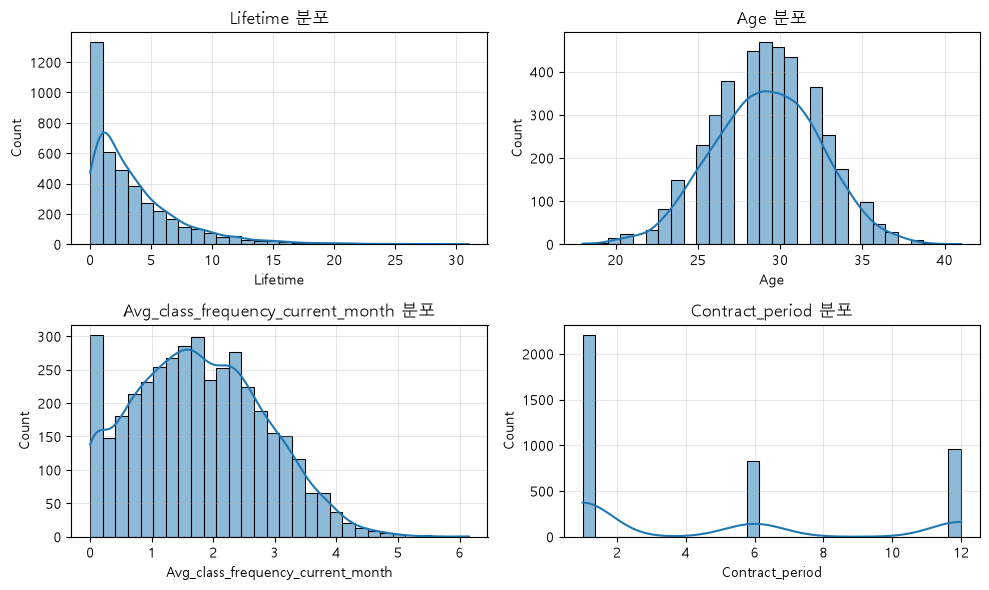

In [8]:
numeric_features = ['Lifetime', 'Age', 'Avg_class_frequency_current_month', 'Contract_period']

# 변수 데이터 분포 확인
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    sns.histplot(cluster_df, x=col, bins=30, kde=True, ax=axes[idx])

    axes[idx].set_title(f"{col} 분포")
    axes[idx].grid(alpha=0.3)
    
plt.tight_layout()
plt.show()


- 분석
    - 이용기간은 왼쪽으로 왜도가 있다.
    - 나이는 정규분포를 보이고 있다.
    - 월 평균 방문 빈도는 왼쪽으로 왜도가 보인다.
    - 계약기간은 2개월 미만에 대부분 몰려 있다.

일부 변수에서 왜도가 보이나 전부 실제 값으로 판단된다.

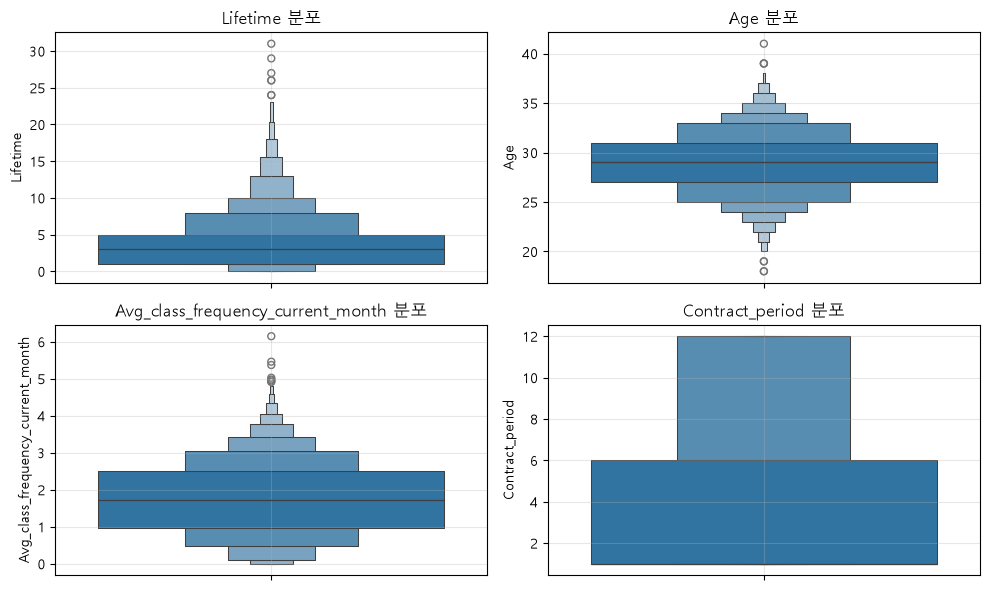

In [9]:
# 변수 데이터 이상치 확인
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    sns.boxenplot(cluster_df, y=col, ax=axes[idx])

    axes[idx].set_title(f"{col} 분포")
    axes[idx].grid(alpha=0.3)
    
plt.tight_layout()
plt.show()


- 분석
    - 이상치가 보이긴 하나 전부 실제 값으로 판단된다.

# 변수간 상관관계 확인

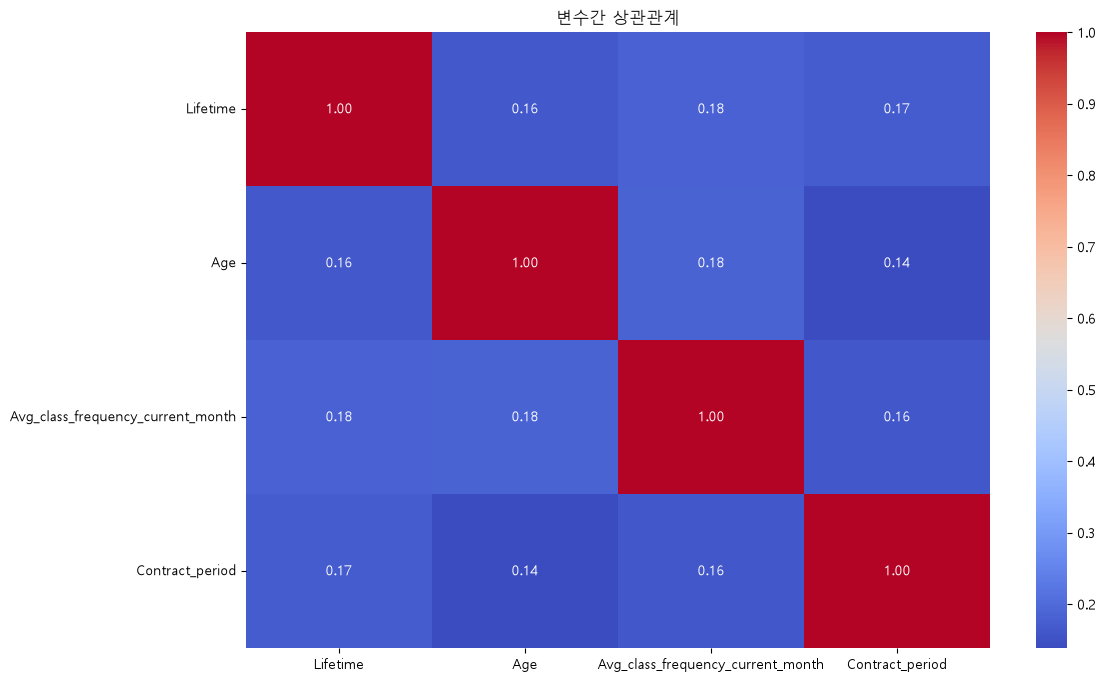

In [10]:
corr = cluster_df[numeric_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('변수간 상관관계')
plt.show()

- 분석  
변수간 상관관계가 거의 없다.

# 5. 데이터 분리

In [11]:
cluster_features = [
    'Lifetime',
    'Age',
    'Avg_class_frequency_current_month',
    'Contract_period'
]

target = "Churn"

X_cluster = cluster_df[cluster_features]
y_cluster = cluster_df[target]

In [12]:
from sklearn.model_selection import train_test_split

# 데이터 분리 함수
def split_data(X, y, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=SEED,
        stratify=y # 학습이 아닌 비교를 위한 사용
    )
    
    return X_train, X_test, y_train, y_test

In [13]:
X_train, X_test, y_train, y_test = split_data(X_cluster, y_cluster)

# 분리된 데이터 확인
print(f"{X_train.shape}, {X_test.shape}, {y_train.shape}, {y_test.shape}")

(3200, 4), (800, 4), (3200,), (800,)


# 6. 전처리 파이프라인

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 전처리 파이프라인
def preprocess_pipeline(n_cluster):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=n_cluster, random_state=SEED, n_init=10))
    ])
    
    return pipeline

# 학습 함수
def train_model(pipeline, X_train):
    pipeline.fit(X_train)
    
    return pipeline

# 추론 함수
def predict_cluster(pipeline, X):
    cluster = pipeline.predict(X)

    return cluster

# 7. 학습 / 추론

In [15]:
n_cluster = 3
# 전처리 파이프라인 적용
pipeline = preprocess_pipeline(n_cluster)

# 모델 학습
pipeline = train_model(pipeline, X_train)

In [16]:
# 학습 추론
train_cluster = predict_cluster(pipeline, X_train)

# 테스트 추론
test_cluster = predict_cluster(pipeline, X_test)

# 8. 검증

In [17]:
from sklearn.metrics import silhouette_score
import pandas as pd

# 후보 검증 함수
def validate_k(X_train, k_range):

    results = []

    for n_cluster in k_range:

        pipeline = preprocess_pipeline(n_cluster)

        pipeline.fit(X_train)

        # 전처리된 데이터
        X_train_scaled = pipeline.named_steps['scaler'].transform(X_train)

        # 군집 결과
        labels = pipeline.named_steps['kmeans'].labels_

        # Silhouette Score
        silhouette = silhouette_score(X_train_scaled, labels)

        # Inertia
        inertia = pipeline.named_steps['kmeans'].inertia_

        results.append({
            'K': n_cluster,
            'Inertia': inertia,
            'Silhouette': silhouette
        })

    return pd.DataFrame(results)

In [18]:
# 검증 분석
k_results = validate_k(
    X_train,
    range(2, 11)
)

k_results

,K,Inertia,Silhouette
0,2,9575.421274,0.253258
1,3,7743.520337,0.259679
2,4,6464.661677,0.267348
3,5,5630.454683,0.248677
4,6,5169.906168,0.237162
5,7,4729.233090,0.235903
6,8,4456.379026,0.233346
7,9,4202.907610,0.232743
8,10,3966.973193,0.212681


In [19]:
import matplotlib.pyplot as plt

# 검증 시각화 함수
def plot_k_validation(results):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow Method
    axes[0].plot(
        results['K'],
        results['Inertia'],
        marker='o'
    )

    axes[0].set_title(
        'Elbow Method'
    )

    axes[0].set_xlabel(
        'Number of Clusters (K)'
    )

    axes[0].set_ylabel(
        'Inertia'
    )

    # Silhouette Score
    axes[1].plot(
        results['K'],
        results['Silhouette'],
        marker='o'
    )

    axes[1].set_title(
        'Silhouette Score'
    )

    axes[1].set_xlabel(
        'Number of Clusters (K)'
    )

    axes[1].set_ylabel(
        'Silhouette Score'
    )

    plt.tight_layout()
    plt.show()

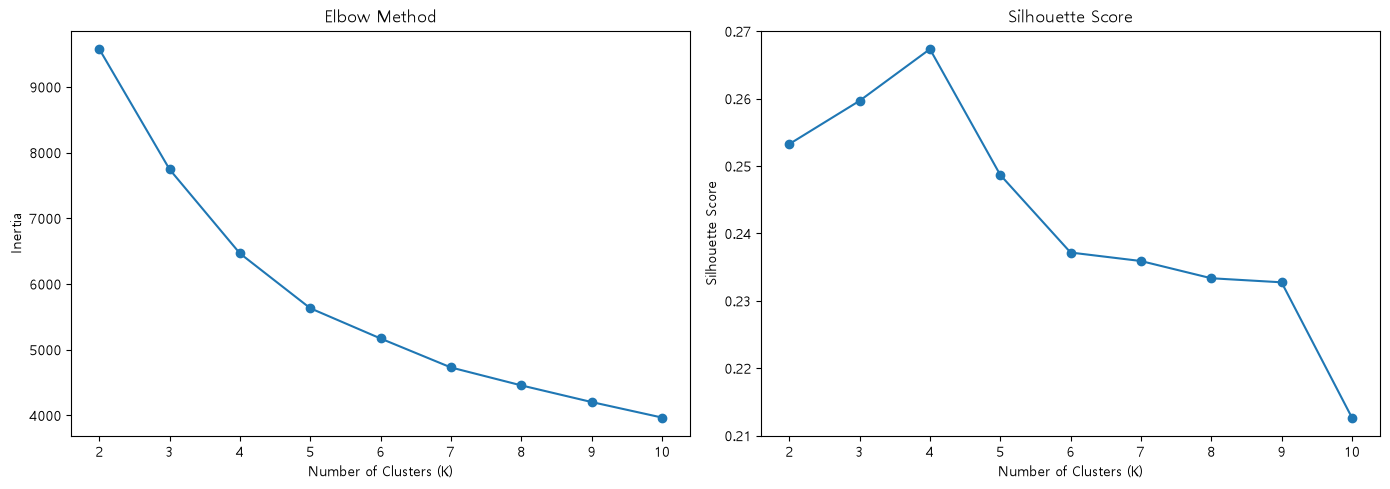

In [20]:
plot_k_validation(k_results)

- 분석
    - Elbow Method는 4부터는 완만해 지기 시작한다.
    - Silhouette Score는 4에서 가장 높은 값을 나타낸다.

- 결론: 가장 최적의 k는 4로 선정

In [21]:
# 최적 k 설정
best_k = 4

pipeline = preprocess_pipeline(
    n_cluster=best_k
)

# 최적 k 적용해서 다시 학습
pipeline = train_model(pipeline, X_train)

In [22]:
from sklearn.metrics import silhouette_score

# 클러스터링 모델의 성능과 데이터 분포를 평가하는 검증 함수
def validate_model(pipeline, X_train, X_test):

    # 전처리
    X_train_scaled = pipeline.named_steps["scaler"].transform(X_train)
    X_test_scaled = pipeline.named_steps["scaler"].transform(X_test)

    # 군집 예측
    train_cluster = pipeline.predict(X_train)
    test_cluster = pipeline.predict(X_test)

    # Silhouette Score
    train_score = silhouette_score(
        X_train_scaled,
        train_cluster
    )

    test_score = silhouette_score(
        X_test_scaled,
        test_cluster
    )

    # 군집 개수
    train_count = (
        pd.Series(train_cluster)
        .value_counts()
        .sort_index()
    )

    test_count = (
        pd.Series(test_cluster)
        .value_counts()
        .sort_index()
    )

    return {
        "train_cluster": train_cluster,
        "test_cluster": test_cluster,
        "train_score": train_score,
        "test_score": test_score,
        "train_count": train_count,
        "test_count": test_count
    }

In [23]:
import matplotlib.pyplot as plt

# 검증 시각화
def plot_validation(result):

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Train/Test Silhouette
    score_df = pd.DataFrame({
        "Train":[result["train_score"]],
        "Test":[result["test_score"]]
    })

    score_df.plot(
        kind="bar",
        ax=axes[0],
        color=["steelblue","tomato"]
    )

    axes[0].set_title("학습 데이터 vs 평가 데이터 실루엣 점수")
    axes[0].set_ylabel("점수")
    axes[0].set_xticklabels(
        ["Silhouette"],
        rotation=0
    )

    # Cluster Distribution
    cluster_df = pd.DataFrame({
        "Train":result["train_count"],
        "Test":result["test_count"]
    })

    cluster_df.plot(
        kind="bar",
        ax=axes[1]
    )

    axes[1].set_title("군집별 데이터 분포")
    axes[1].set_xlabel("클러스터")
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].set_ylabel("개수")

    plt.tight_layout()
    plt.show()

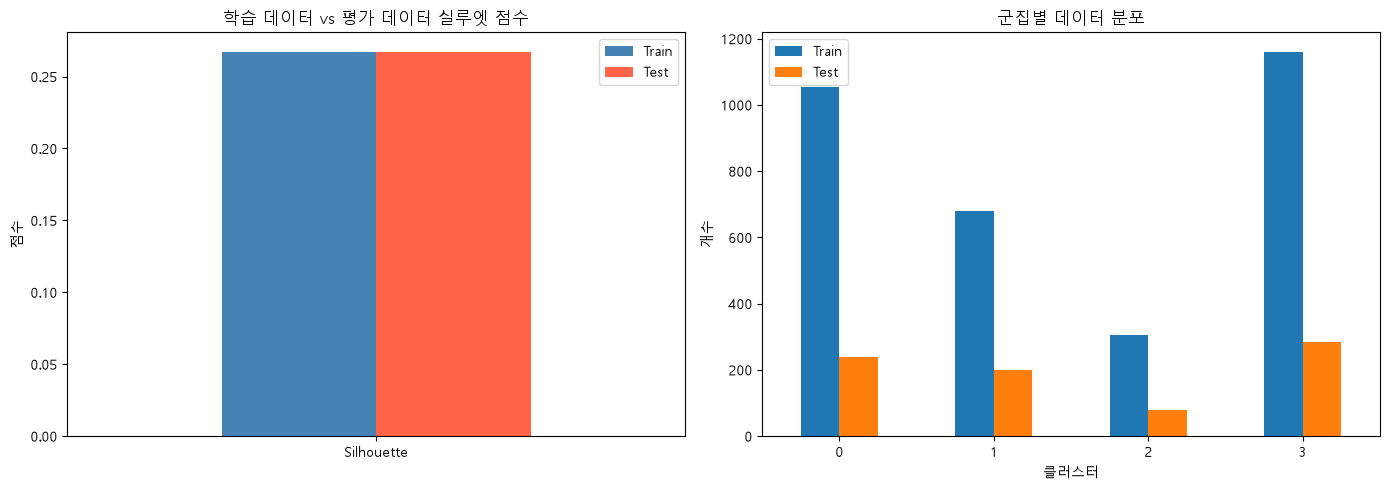

In [24]:
validation_result = validate_model(
    pipeline,
    X_train,
    X_test
)

plot_validation(validation_result)

- 분석
    - train과 test 점수가 거의 비슷하므로 과적합은 아니다.
    - 군집간 데이터 불균형은 존재하지만, 모든 클러스터에서 데이터가 일정한 비율로 잘 분배되어 있다.

# 9. 평가

In [25]:
# 원본 피처 데이터, 정답, 예측 군집 라벨을 결합한 데이터프레임을 생성하는 함수
def make_cluster_result(X, y, cluster):
    result = X.copy()

    result["Cluster"] = cluster
    result["Churn"] = y.values

    return result

In [26]:
# 학습 데이터에 대해 피처, 정답, 군집 예측 결과를 하나로 결합
train_result = make_cluster_result(
    X_train,
    y_train,
    validation_result["train_cluster"]
)

# 평가 데이터에 대해 피처, 정답, 군집 예측 결과를 하나로 결합
test_result = make_cluster_result(
    X_test,
    y_test,
    validation_result["test_cluster"]
)

In [27]:
# 학습 데이터 기준으로 군집별 지정된 피처들의 평균값 계산
cluster_mean = (
    train_result
    .groupby("Cluster")[cluster_features]
    .mean()
)

In [28]:
# 계산된 군집별 피처 평균값을 히트맵으로 시각화하는 함수
def plot_cluster_feature(cluster_mean):

    plt.figure(figsize=(10,6))

    sns.heatmap(
        cluster_mean.T,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )

    plt.title("군집별 특성 평균")
    plt.tight_layout()
    plt.show()

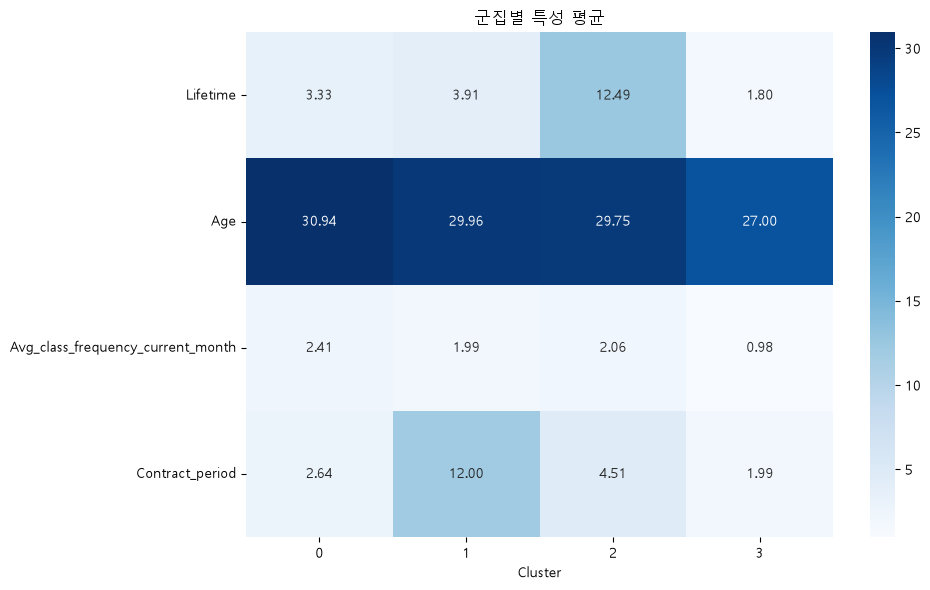

In [29]:
plot_cluster_feature(cluster_mean)

- 분석
    - **0번 클러스터**는 이용기간은 3개월 나이는 30 월 평균 이용 빈도는 2회 계약기간은 2개월로 보아   
    **단기계약** 회원으로 보임
    - **1번 클러스터**는 이용기간은 3개월 나이는 29 월 평균 이용 빈도는 1회 계약기간은 1년으로 보아  
    **장기 계약** 회원으로 보임
    - **2번 클러스터**는 이용기간은 1년 나이는 29 월 평균 이용 빈도는 2회 계약기간은 4회로 보아  
    **VIP** 회원으로 보임
    - **3번 클러스터**는 이용기간은 1개월 나이는 27 월 평균 이용 빈도는 0.9회 계약기간은 1회로 보아  
    **이탈 위험** 회원으로 보임

In [30]:
# Cluster별 Churn 계산
def evaluate_cluster_churn(train_result, test_result):
    train = (
        train_result
        .groupby('Cluster')['Churn']
        .mean()
    )

    test = (
        test_result
        .groupby('Cluster')['Churn']
        .mean()
    )

    return pd.DataFrame({
        'Train':train,
        'Test':test
    })

In [31]:
cluster_churn = evaluate_cluster_churn(
    train_result,
    test_result
)

In [32]:
# Cluster별 Churn 시각화
def plot_cluster_churn(cluster_churn):
    cluster_churn.plot(
        kind='bar',
        figsize=(8,5)
    )

    plt.title('클래스터 별 이탈률')
    plt.xlabel('클래스터')
    plt.ylabel('이탈률')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

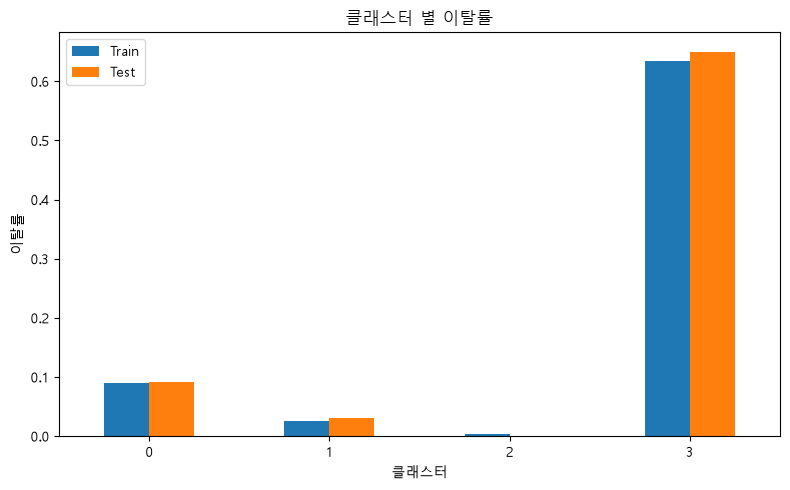

In [33]:
plot_cluster_churn(cluster_churn)

- 분석  
클래스터의 학습 / 테스터 데이터의 과적합은 없어 보인다.  
3번 클래스터가 가장 이탈률이 높다

In [34]:
from sklearn.decomposition import PCA

# # PCA를 활용하여 2차원 평면에 클러스터 분포를 시각화하는 함수
def plot_cluster_pca(pipeline, X, cluster):
    scaler = pipeline.named_steps['scaler']

    X_scaled = scaler.transform(X)

    pca = PCA(
        n_components=2,
        random_state=SEED
    )

    X_pca = pca.fit_transform(
        X_scaled
    )

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        x=X_pca[:,0],
        y=X_pca[:,1],
        hue=cluster,
        palette='Set2'
    )

    plt.title('PCA 군집 분포도')

    plt.tight_layout()
    plt.show()

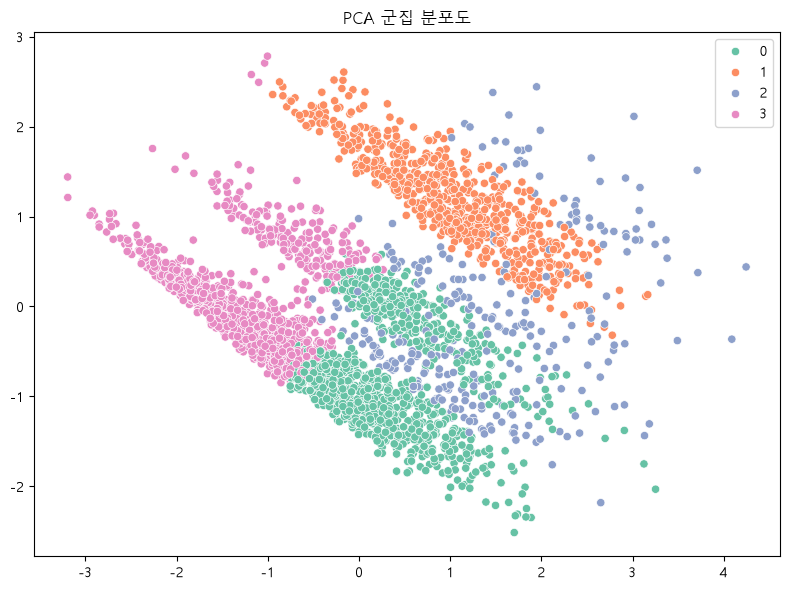

In [35]:
plot_cluster_pca(
    pipeline,
    X_train,
    validation_result['train_cluster']
)

- 분석  
0, 1, 3번 클러스터는 군집이 잘 형성되어 있으면 2번 클러스터는 널리 퍼져있어 다양한 회원들이 있다는 걸 알 수 있다.

# 10. 고도화

In [36]:
# 고도화 Feature
cluster_features_upgrade = [
    'Lifetime',
    'Age',
    'Avg_class_frequency_current_month',
    'Contract_period',
]

target = "Churn"

X_cluster_upgrade = cluster_df[cluster_features_upgrade]
y_cluster_upgrade = cluster_df[target]

X_train_upgrade, X_test_upgrade, y_train_upgrade, y_test_upgrade = split_data(
    X_cluster_upgrade,
    y_cluster_upgrade
)

RobustScaler를 이용한 고도화

In [37]:
from sklearn.preprocessing import RobustScaler

# 고도화 전처리 Pipeline
def preprocess_pipeline_upgrade(n_cluster):
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('kmeans', KMeans(
            n_clusters=n_cluster,
            random_state=SEED,
            n_init=10
        ))
    ])

    return pipeline

In [ ]:
# RobustScaler를 적용한 상태의 K 검증 함수
def validate_k_upgrade(X_train, k_range):
    results = []

    for n_cluster in k_range:
        pipeline = preprocess_pipeline_upgrade(n_cluster)

        pipeline.fit(X_train)

        X_scaled = pipeline.named_steps["scaler"].transform(X_train)

        labels = pipeline.named_steps["kmeans"].labels_

        silhouette = silhouette_score(X_scaled, labels)

        inertia = pipeline.named_steps["kmeans"].inertia_

        results.append({
            "K": n_cluster,
            "Inertia": inertia,
            "Silhouette": silhouette
        })

    return pd.DataFrame(results)

In [39]:
k_results_upgrade = validate_k_upgrade(
    X_train_upgrade,
    range(2, 11)
)

k_results_upgrade

,K,Inertia,Silhouette
0,2,6586.613861,0.303553
1,3,5173.675521,0.307731
2,4,4182.836806,0.274405
3,5,3773.366238,0.260317
4,6,3485.425878,0.235084
5,7,3200.574472,0.238686
6,8,2963.326405,0.226016
7,9,2749.409093,0.231245
8,10,2597.008453,0.238347


In [48]:
def plot_k_validation_upgrade(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow Method
    axes[0].plot(
        results["K"],
        results["Inertia"],
        marker="o"
    )

    axes[0].set_title("Elbow Method - RobustScaler")
    axes[0].set_xlabel("Number of Clusters (K)")
    axes[0].set_ylabel("Inertia")

    # Silhouette Score
    axes[1].plot(
        results["K"],
        results["Silhouette"],
        marker="o"
    )

    axes[1].set_title("Silhouette Score - RobustScaler")
    axes[1].set_xlabel("Number of Clusters (K)")
    axes[1].set_ylabel("Silhouette Score")

    plt.tight_layout()
    plt.show()

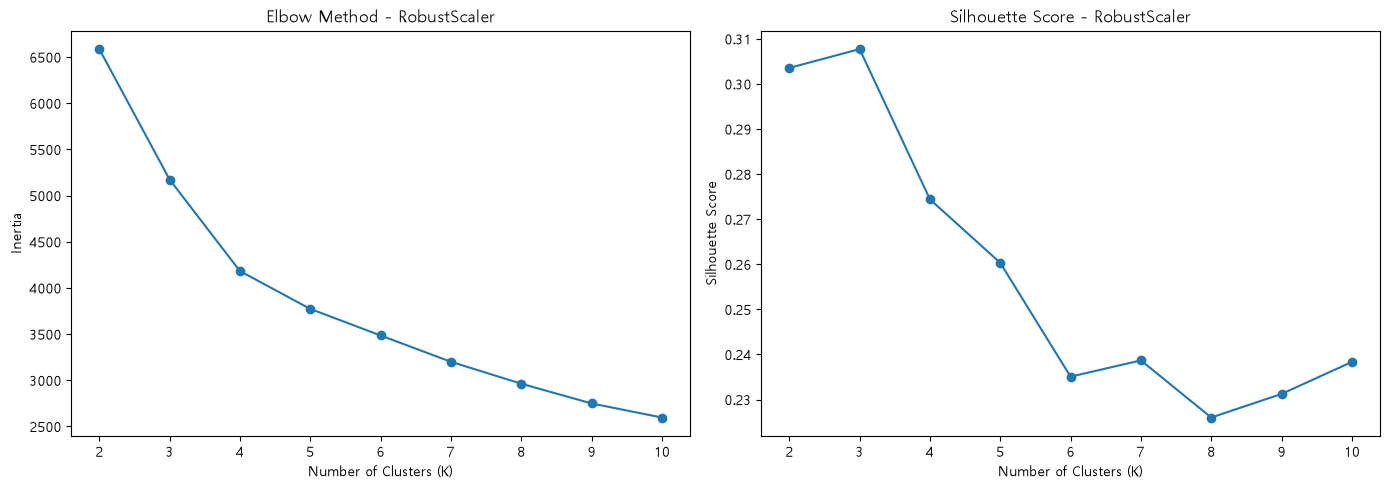

In [49]:
plot_k_validation_upgrade(k_results_upgrade)

- 분석
    - 고도화 후 최적 클러스터는 전과는 달리 3으로 측정된다.


다시 측정한 K로 학습 / 추론

In [51]:
best_k_upgrade = 3

pipeline_upgrade = preprocess_pipeline_upgrade(
    best_k_upgrade
)

pipeline_upgrade = train_model(
    pipeline_upgrade,
    X_train_upgrade
)

# Train 추론
train_cluster_upgrade = predict_cluster(
    pipeline_upgrade,
    X_train_upgrade
)

# Test 추론
test_cluster_upgrade = predict_cluster(
    pipeline_upgrade,
    X_test_upgrade
)

In [ ]:
# 고도화 모델 평가
def evaluate_upgrade(pipeline, X_train, X_test):
    X_train_scaled = pipeline.named_steps["scaler"].transform(X_train)
    X_test_scaled = pipeline.named_steps["scaler"].transform(X_test)

    train_cluster = pipeline.predict(X_train)
    test_cluster = pipeline.predict(X_test)

    train_score = silhouette_score(X_train_scaled, train_cluster)
    test_score = silhouette_score(X_test_scaled, test_cluster)

    return {
        "train_score": train_score,
        "test_score": test_score,
        "train_cluster": train_cluster,
        "test_cluster": test_cluster
    }

In [55]:
validation_result_upgrade = evaluate_upgrade(
    pipeline_upgrade,
    X_train_upgrade,
    X_test_upgrade
)

print(f"Train Silhouette: {validation_result_upgrade['train_score']:.4f}")
print(f"Test Silhouette: {validation_result_upgrade['test_score']:.4f}")

Train Silhouette: 0.3077
Test Silhouette: 0.3130


In [57]:
# 고도화 모델 Cluster 분석
train_result_upgrade = make_cluster_result(
    X_train_upgrade,
    y_train_upgrade,
    validation_result_upgrade["train_cluster"]
)

test_result_upgrade = make_cluster_result(
    X_test_upgrade,
    y_test_upgrade,
    validation_result_upgrade["test_cluster"]
)

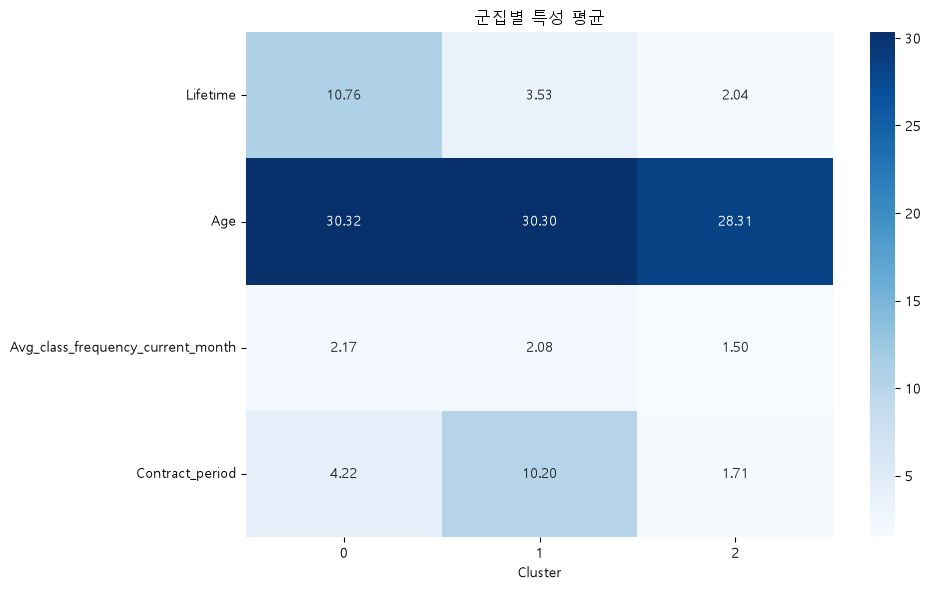

In [58]:
cluster_mean_upgrade = (
    train_result_upgrade
    .groupby("Cluster")[cluster_features_upgrade]
    .mean()
)

plot_cluster_feature(cluster_mean_upgrade)

- 분석  
**0번 클러스터**는 이용기간이 긴걸로 보아 **VIP 회원**으로 보인다.  
**1번 클러스터**는 계약기간이 긴걸로 보아 **장기 계약 회원**으로 보인다.  
**2번 클러스터**는 전체적으로 기간이 짧은 걸로 보아 **이탈 위험 회원**으로 보인다.  

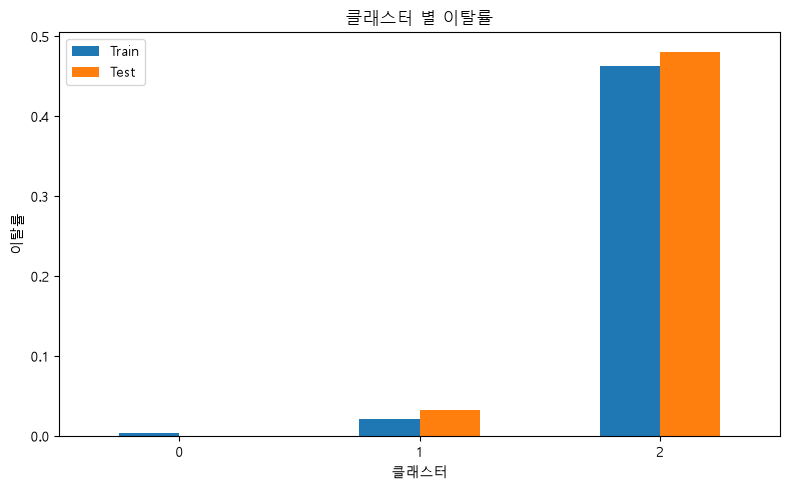

In [59]:
cluster_churn_upgrade = evaluate_cluster_churn(
    train_result_upgrade,
    test_result_upgrade
)

plot_cluster_churn(
    cluster_churn_upgrade
)

- 분석  
2번 클러스터가 이탈률이 가장 높다. 2번 클러스터가 이탈 위험고객이라 높은 것으로 보인다.

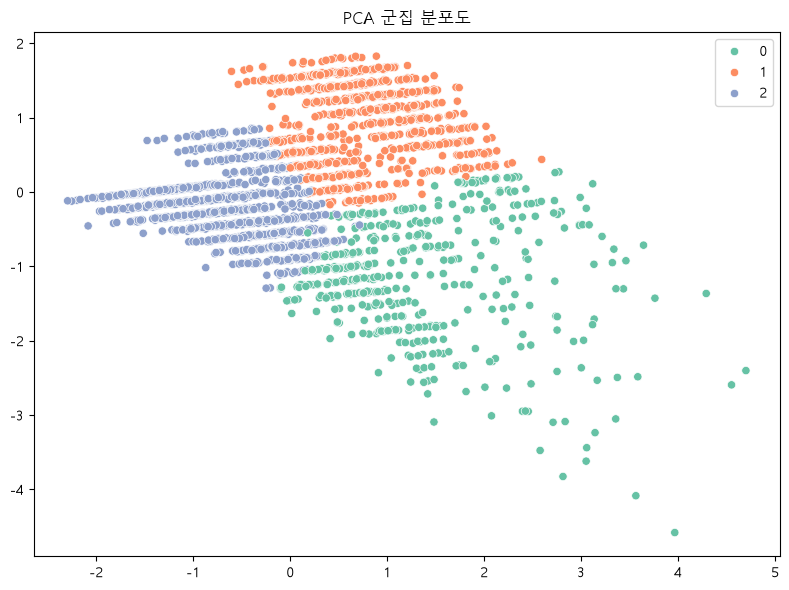

In [61]:
plot_cluster_pca(
    pipeline_upgrade,
    X_train_upgrade,
    validation_result_upgrade["train_cluster"]
)

- 분석  
1, 2번 클러스터는 대채적을 군집이 잘 형성 되어 있고, 2번은 널리 퍼져있는 것으로 보아  
다양한 회원들 속해 있는것으로 보인다.

In [73]:
import joblib

# 모델 저장
joblib.dump(pipeline, "../models/analysis1/churn_cluster_model.joblib")

['../models/analysis1/churn_cluster_model.joblib']